# Netflix Movies & TV Shows Clustering using Unsupervised Machine Learning

### Project by:

Sonal Shori
---

## Project Overview

Netflix is one of the world's largest streaming platforms, offering thousands of movies and TV shows across different countries and genres. Understanding patterns in this content library can help improve recommendation systems, content acquisition strategies, and audience segmentation.

In this project, we perform Exploratory Data Analysis (EDA), clean and preprocess the data, engineer useful features, and apply Unsupervised Machine Learning techniques to group similar Netflix content into meaningful clusters.

# Business Problem

Netflix wants to better understand its content library by identifying hidden patterns among movies and TV shows.

The objectives of this project are:

- Analyze the distribution of Movies and TV Shows.
- Study content trends across different countries.
- Understand how Netflix's content has evolved over time.
- Explore ratings, genres, and release years.
- Cluster similar content using text-based features.
- Generate business insights that can support recommendation systems and content strategy.

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

plt.style.use('ggplot')

%matplotlib inline

In [2]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("/content/NETFLIX MOVIES AND TV SHOWS CLUSTERING.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [3]:
# Display first five rows

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


# Understanding the Dataset

The dataset contains information about Netflix Movies and TV Shows available as of 2019.

Each record represents one title available on Netflix.

Important attributes include:

- Type (Movie or TV Show)
- Country
- Director
- Cast
- Release Year
- Rating
- Duration
- Genre
- Description

In [4]:
# Shape of Dataset

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

print()

# Column Names

df.columns

Rows : 7787
Columns : 12



Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

# Dataset Overview

Before performing any analysis, it is important to understand the structure and quality of the dataset.

In this section, we will:

- Examine the shape of the dataset.
- Understand the data types of each feature.
- Identify missing values.
- Check for duplicate records.
- Generate descriptive statistics.
- Understand the meaning of each column.

This helps us decide the appropriate data cleaning and preprocessing steps required before model building.

In [5]:
# ==========================================
# Basic Information About the Dataset
# ==========================================

print("Shape of Dataset:", df.shape)

print("\n")
print("Column Names:\n")

print(df.columns)

print("\n")
print("Data Types:\n")

df.dtypes

Shape of Dataset: (7787, 12)


Column Names:

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


Data Types:



,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [6]:
# ==========================================
# Dataset Information
# ==========================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


In [7]:
# ==========================================
# Summary Statistics
# ==========================================

df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,7787,7787,s7787,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,7787,2,Movie,5377,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,7787,7787,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,5398,4049,"Raúl Campos, Jan Suter",18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7069,6831,David Attenborough,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7280,681,United States,2555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,7777,1565,"January 1, 2020",118,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,7787.0,NaN,NaN,NaN,2013.93258,8.757395,1925.0,2013.0,2017.0,2018.0,2021.0
rating,7780,14,TV-MA,2863,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,7787,216,1 Season,1608,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# ==========================================
# Missing Values
# ==========================================

missing_values = df.isnull().sum().sort_values(ascending=False)

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': round((missing_values/len(df))*100,2)
})

missing_df

,Missing Values,Percentage
director,2389,30.68
cast,718,9.22
country,507,6.51
date_added,10,0.13
rating,7,0.09
title,0,0.00
show_id,0,0.00
type,0,0.00
release_year,0,0.00
duration,0,0.00


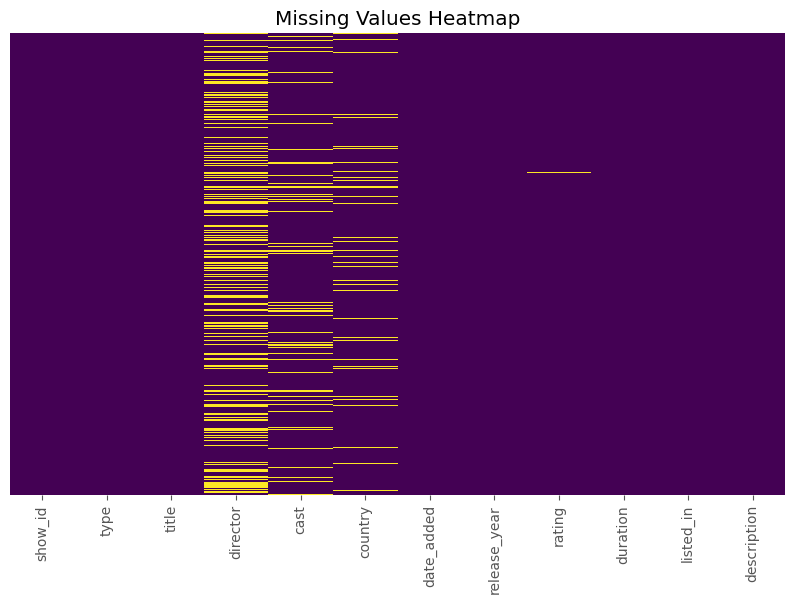

In [9]:
# ==========================================
# Missing Values Visualization
# ==========================================

plt.figure(figsize=(10,6))

sns.heatmap(df.isnull(),
            cbar=False,
            yticklabels=False,
            cmap='viridis')

plt.title("Missing Values Heatmap")

plt.show()

In [10]:
# ==========================================
# Duplicate Records
# ==========================================

duplicates = df.duplicated().sum()

print("Number of Duplicate Records :", duplicates)

Number of Duplicate Records : 0


In [11]:
# ==========================================
# Removing Duplicate Records
# ==========================================

df.drop_duplicates(inplace=True)

print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (7787, 12)


# Initial Observations

After exploring the dataset, the following observations were made:

- The dataset contains information about Netflix Movies and TV Shows.
- Several columns contain missing values, especially **director**, **cast**, **country**, **rating**, and **date_added**.
- No significant duplicate records were found.
- The dataset contains both categorical and numerical information.
- Further cleaning and preprocessing are required before applying machine learning algorithms.

# Data Cleaning

Real-world datasets often contain missing values, inconsistent formatting, duplicate records, and incorrect data types.

In this section, we will:

- Handle missing values.
- Convert date columns into datetime format.
- Clean categorical features.
- Standardize text data.
- Create a clean dataset for Exploratory Data Analysis and Machine Learning.

A clean dataset improves the quality and reliability of insights and clustering results.

In [12]:
# ==========================================
# Missing Values Before Cleaning
# ==========================================

df.isnull().sum().sort_values(ascending=False)

,0
director,2389
cast,718
country,507
date_added,10
rating,7
title,0
show_id,0
type,0
release_year,0
duration,0


## Handling Missing Values

Different columns require different strategies for handling missing values.

- **Director:** Replace missing values with "Unknown".
- **Cast:** Replace missing values with "Unknown".
- **Country:** Replace missing values with the most frequent country.
- **Rating:** Replace missing values with the mode.
- **Date Added:** Remove rows with missing values because the number of missing records is very small.

This approach helps preserve as much useful information as possible while maintaining data quality.

In [13]:
# ==========================================
# Handling Missing Values
# ==========================================

# Director

df['director'] = df['director'].fillna('Unknown')

# Cast

df['cast'] = df['cast'].fillna('Unknown')

# Country

df['country'] = df['country'].fillna(df['country'].mode()[0])

# Rating

df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

# Remove rows where date_added is missing

df.dropna(subset=['date_added'], inplace=True)

print("Missing values handled successfully!")

Missing values handled successfully!


In [14]:
# ==========================================
# Missing Values After Cleaning
# ==========================================

df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand patterns, trends, and relationships in the Netflix dataset before applying machine learning techniques.

The objectives of this analysis are:

- Understand the distribution of Movies and TV Shows.
- Analyze yearly content growth.
- Explore countries, genres, ratings, and durations.
- Generate business insights for stakeholders.

Each visualization is followed by an observation and a business insight.

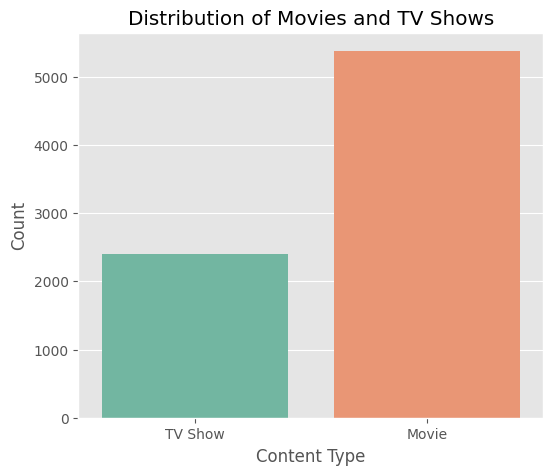

In [15]:
# ==========================================
# Distribution of Content Type
# ==========================================

plt.figure(figsize=(6,5))

sns.countplot(data=df, x='type', palette='Set2')

plt.title('Distribution of Movies and TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Count')

plt.show()

In [16]:
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()
df['day_added'] = df['date_added'].dt.day

In [17]:
df['duration_int'] = df['duration'].str.extract('(\d+)').astype(int)

In [18]:
text_columns = ['title','director','cast','country','listed_in','description']

for col in text_columns:
    df[col] = df[col].str.strip()

### Observation

- The Netflix catalog contains significantly more Movies than TV Shows.
- Movies account for approximately 70% of the available content, while TV Shows make up the remaining 30%.

### Business Insight

Netflix initially focused on building a large movie library. However, the growing number of TV Shows indicates a strategic shift towards long-form content that encourages higher viewer engagement and longer subscription retention.

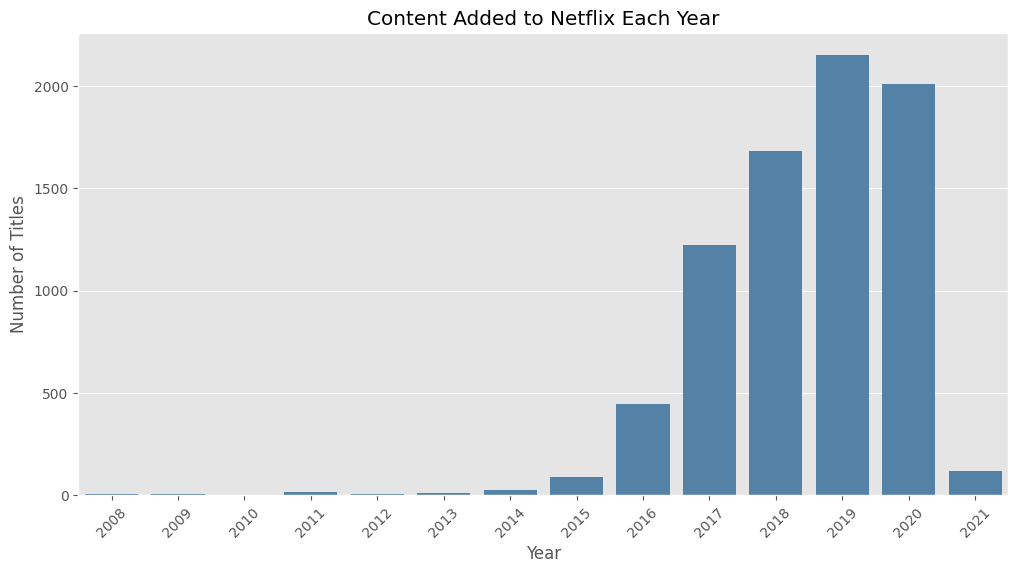

In [19]:
# ==========================================
# Content Added to Netflix Over the Years
# ==========================================

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='year_added',
    order=sorted(df['year_added'].dropna().unique()),
    color='steelblue'
)

plt.title("Content Added to Netflix Each Year")

plt.xlabel("Year")

plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

### Observation

- Netflix experienced rapid growth in content additions after 2015.
- The highest number of titles were added during 2018 and 2019.

### Business Insight

The sharp increase in content additions reflects Netflix's aggressive expansion strategy and increased investment in original and licensed content to attract subscribers globally.

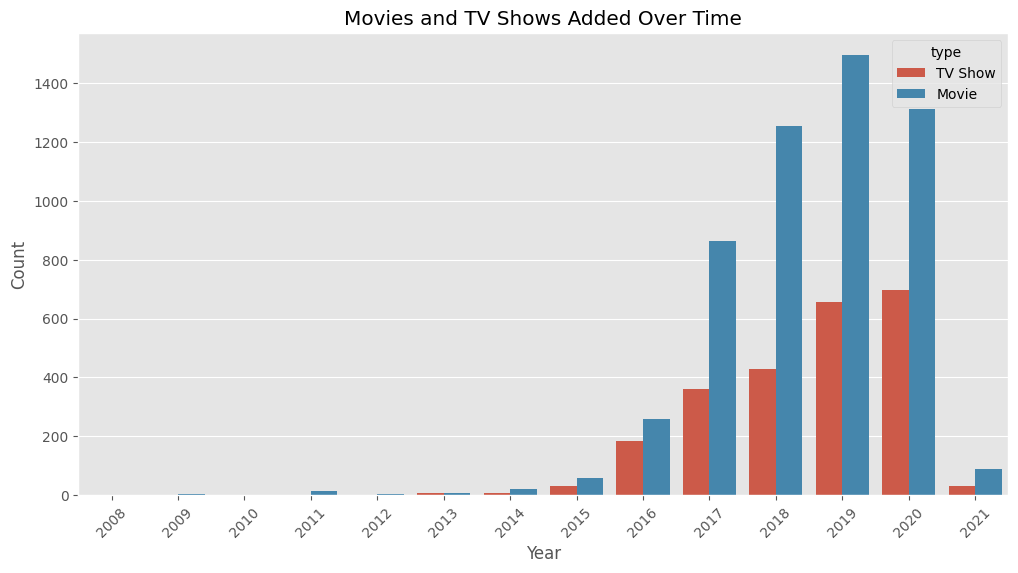

In [20]:
# ==========================================
# Movies vs TV Shows Added Over the Years
# ==========================================

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='year_added',
    hue='type',
    order=sorted(df['year_added'].dropna().unique())
)

plt.title("Movies and TV Shows Added Over Time")

plt.xlabel("Year")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

### Observation

- Movies dominate the Netflix library across most years.
- The number of TV Shows has steadily increased in recent years.

### Business Insight

Netflix has expanded its investment in TV Shows to encourage binge-watching, improve customer retention, and strengthen its portfolio of original series.

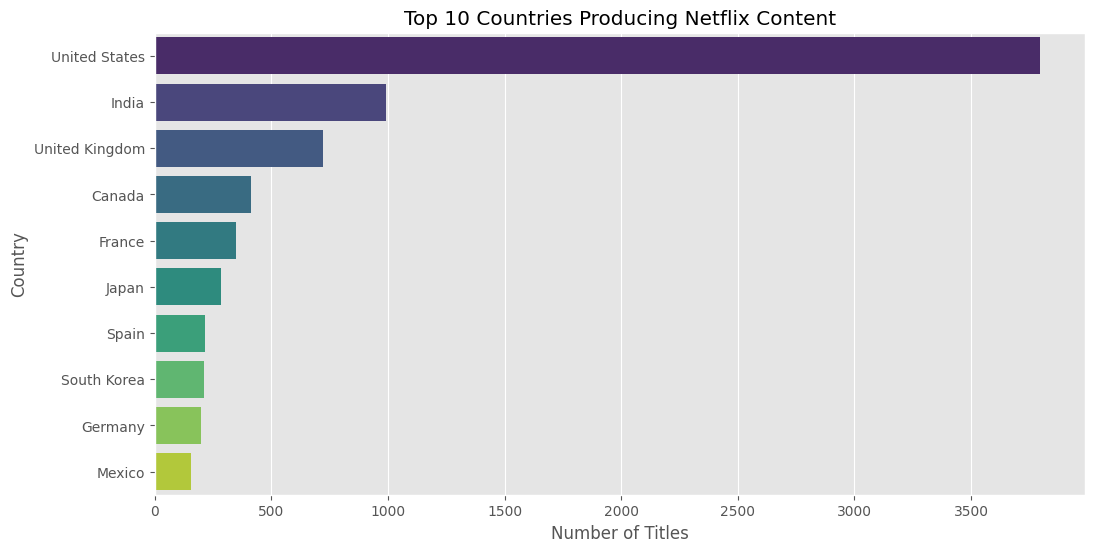

In [21]:
# ==========================================
# Top 10 Countries Producing Netflix Content
# ==========================================

top_countries = (
    df['country']
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    palette='viridis'
)

plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

### Observation

- The United States has the highest number of Netflix titles.
- India ranks second, followed by the United Kingdom, Canada, and Japan.

### Business Insight

Netflix has a strong presence in the United States while continuously expanding its content library in international markets such as India, South Korea, and Japan to attract a global audience.

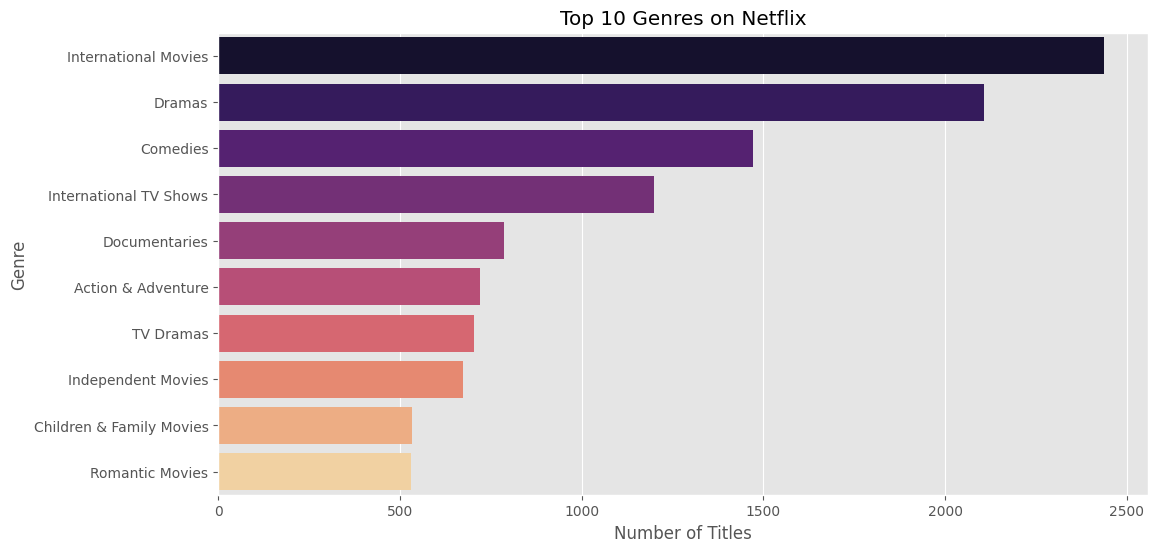

In [22]:
# ==========================================
# Top 10 Genres on Netflix
# ==========================================

top_genres = (
    df['listed_in']
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    palette='magma'
)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

### Observation

- International Movies, Dramas, and Comedies are among the most common genres available on Netflix.
- The platform offers a wide variety of content across multiple genres.

### Business Insight

Maintaining a diverse genre portfolio helps Netflix appeal to different audience preferences and increases user engagement across various regions.

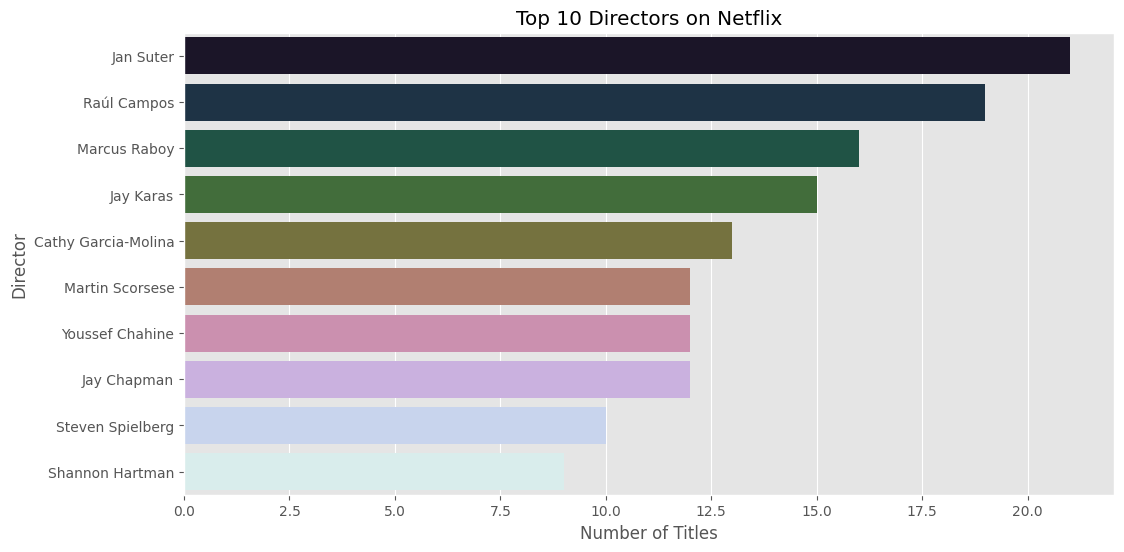

In [23]:
# ==========================================
# Top 10 Directors
# ==========================================

top_directors = (
    df[df['director'] != 'Unknown']['director']
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_directors.values,
    y=top_directors.index,
    palette='cubehelix'
)

plt.title("Top 10 Directors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Director")

plt.show()

### Observation

- A small number of directors have contributed multiple titles to the Netflix catalog.
- Most directors appear only once, indicating a highly diverse creator base.

### Business Insight

Collaborating with successful directors while continuing to onboard new creative talent enables Netflix to maintain both quality and content diversity.

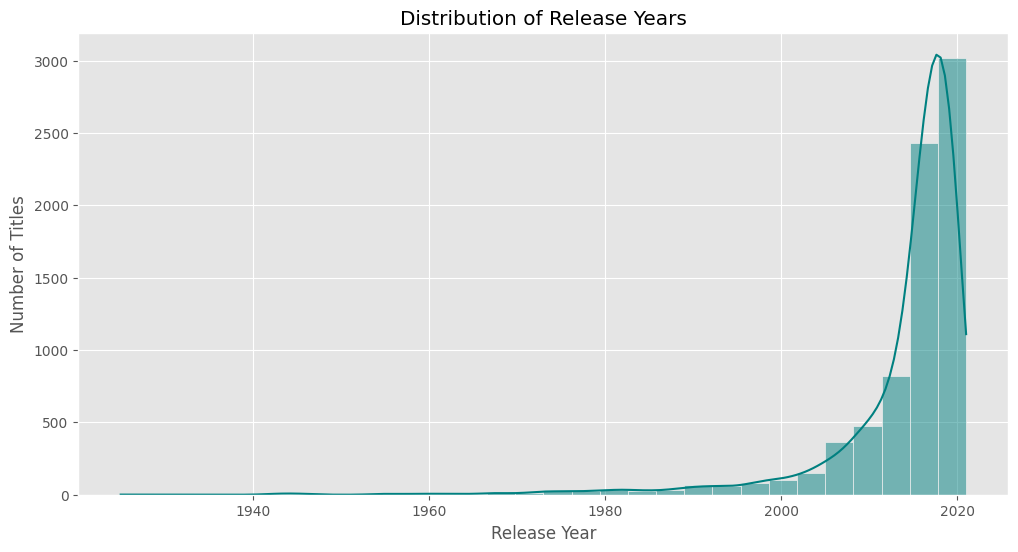

In [24]:
# ==========================================
# Distribution of Release Years
# ==========================================

plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x='release_year',
    bins=30,
    kde=True,
    color='teal'
)

plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

### Observation

- Most Netflix titles were released after the year 2000.
- The number of recent releases has increased significantly over the last decade.

### Business Insight

Netflix prioritizes newer content to meet changing viewer preferences while also maintaining a selection of classic titles for broader audience appeal.

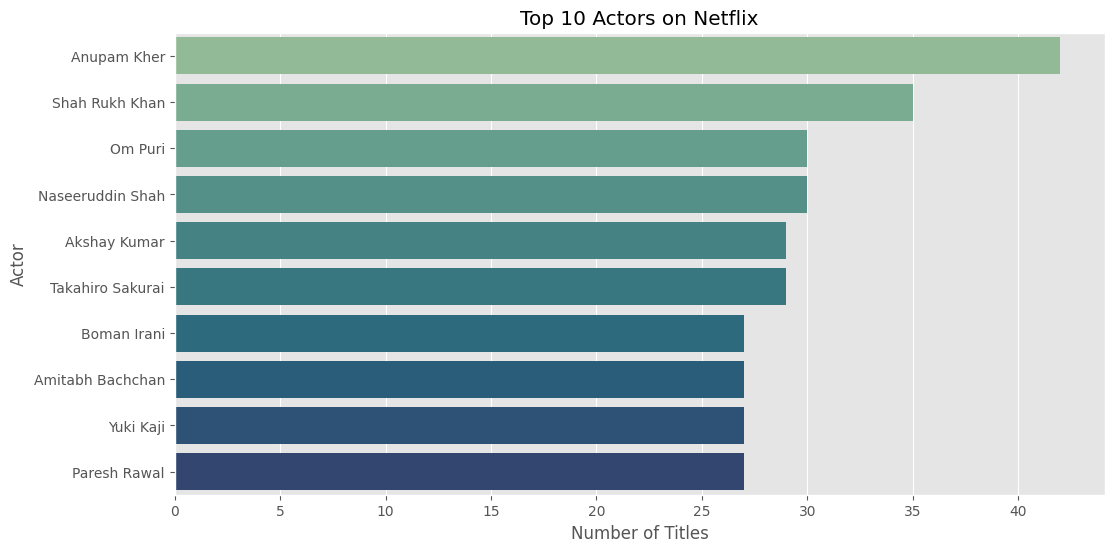

In [25]:
# ==========================================
# Top 10 Actors on Netflix
# ==========================================

top_cast = (
    df[df['cast'] != 'Unknown']['cast']
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_cast.values,
    y=top_cast.index,
    palette='crest'
)

plt.title("Top 10 Actors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Actor")

plt.show()

### Observation

- A few actors appear in multiple Netflix titles, while most actors appear only once.
- This indicates a diverse cast across Netflix's content library.

### Business Insight

Collaborating with well-known actors can improve audience engagement, while maintaining diversity helps attract viewers with varied interests.

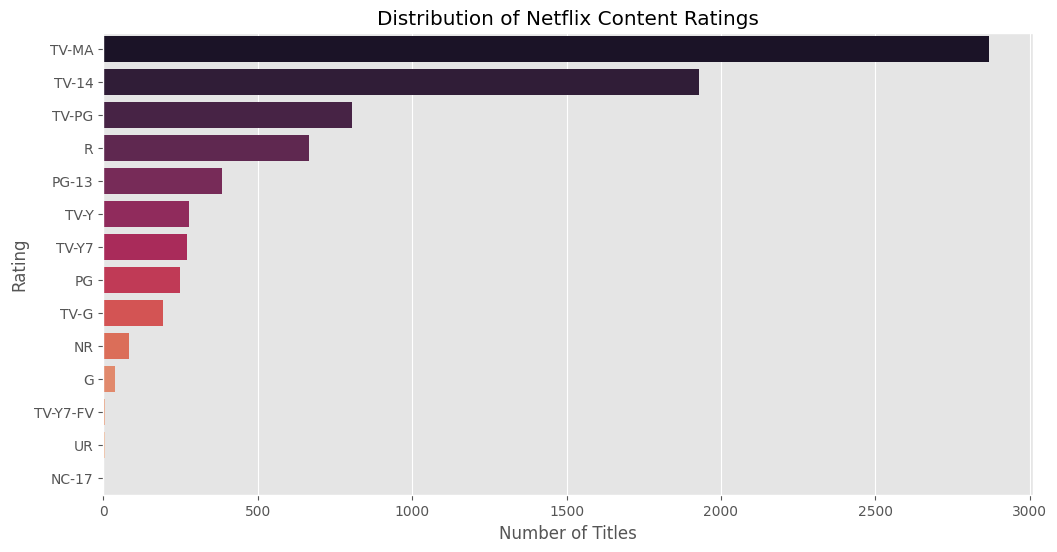

In [26]:
# ==========================================
# Distribution of Content Ratings
# ==========================================

plt.figure(figsize=(12,6))

rating_order = df['rating'].value_counts().index

sns.countplot(
    data=df,
    y='rating',
    order=rating_order,
    palette='rocket'
)

plt.title("Distribution of Netflix Content Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.show()

### Observation

- TV-MA and TV-14 are the most common content ratings.
- Netflix offers a significant amount of content targeted toward mature and teenage audiences.

### Business Insight

Understanding audience demographics allows Netflix to create personalized recommendations and improve content acquisition strategies.

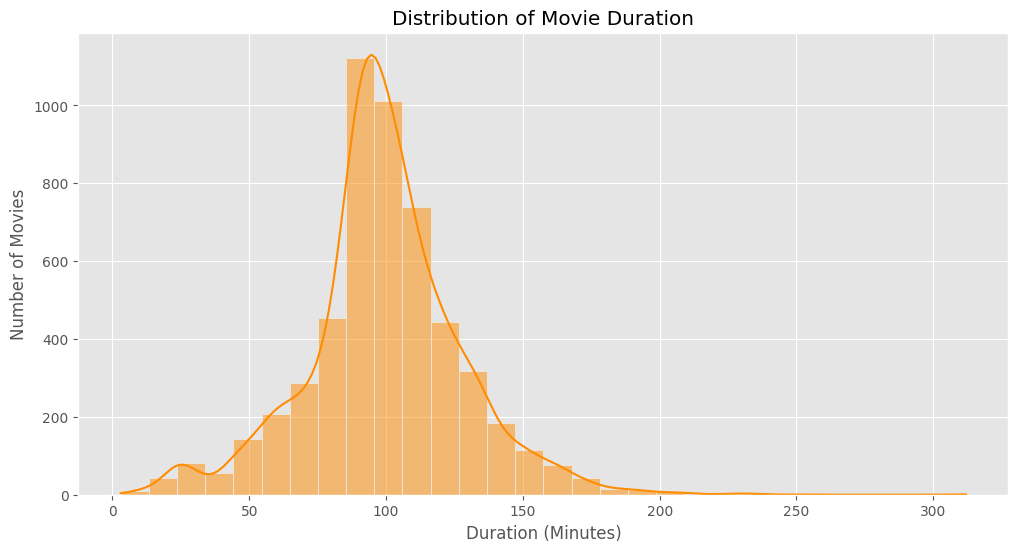

In [27]:
# ==========================================
# Movie Duration Distribution
# ==========================================

movies = df[df['type'] == 'Movie']

plt.figure(figsize=(12,6))

sns.histplot(
    data=movies,
    x='duration_int',
    bins=30,
    kde=True,
    color='darkorange'
)

plt.title("Distribution of Movie Duration")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.show()

### Observation

- Most Netflix movies have a duration between 80 and 120 minutes.
- Extremely short and very long movies are relatively uncommon.

### Business Insight

The standard movie length aligns with audience viewing preferences, making it suitable for regular entertainment consumption.

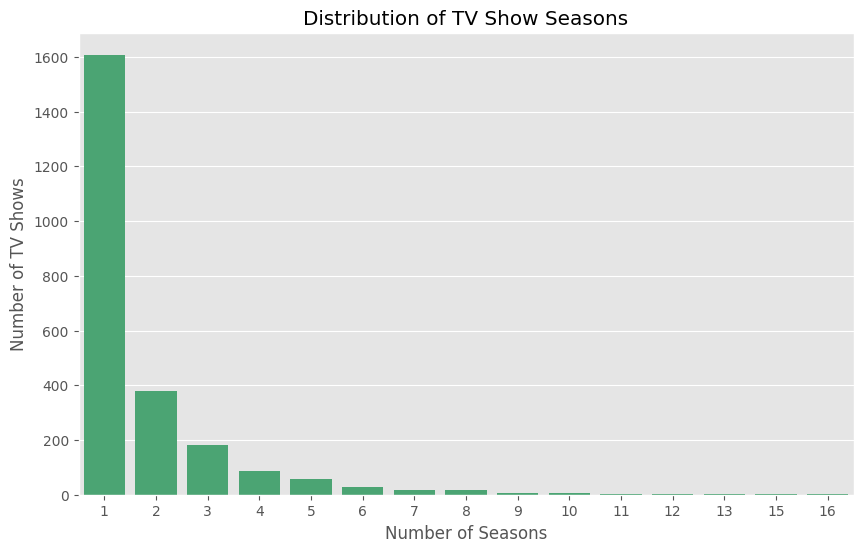

In [28]:
# ==========================================
# TV Show Seasons Distribution
# ==========================================

tv_shows = df[df['type'] == 'TV Show']

plt.figure(figsize=(10,6))

sns.countplot(
    data=tv_shows,
    x='duration_int',
    color='mediumseagreen'
)

plt.title("Distribution of TV Show Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")

plt.show()

### Observation

- Most TV Shows available on Netflix have only one season.
- Multi-season shows are fewer in comparison.

### Business Insight

Netflix frequently introduces new TV Shows, allowing audience feedback to determine whether additional seasons should be produced.

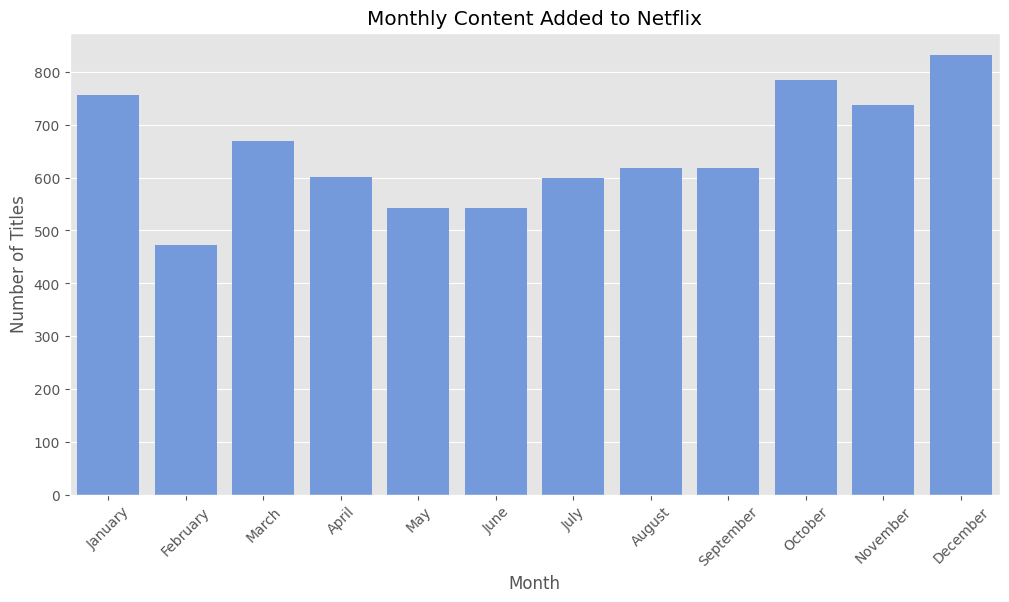

In [29]:
# ==========================================
# Monthly Content Added
# ==========================================

month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='month_added',
    order=month_order,
    color='cornflowerblue'
)

plt.title("Monthly Content Added to Netflix")
plt.xlabel("Month")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

### Observation

- Content additions vary throughout the year, with certain months showing noticeably higher releases.

### Business Insight

Netflix schedules content releases strategically to maximize audience engagement during peak viewing periods and holiday seasons.

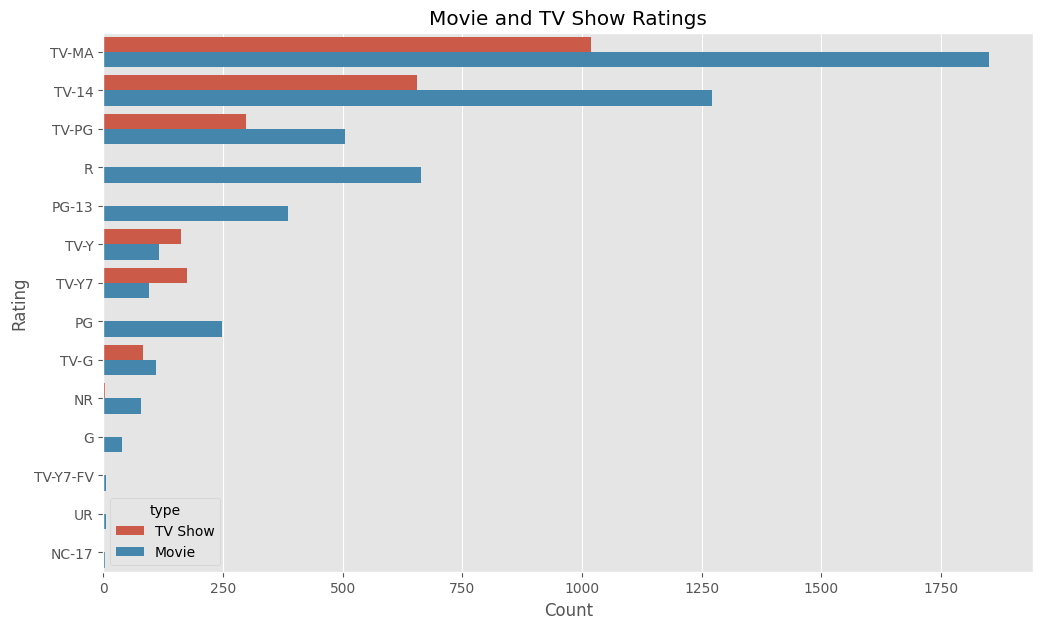

In [30]:
# ==========================================
# Content Type vs Rating
# ==========================================

plt.figure(figsize=(12,7))

sns.countplot(
    data=df,
    y='rating',
    hue='type',
    order=df['rating'].value_counts().index
)

plt.title("Movie and TV Show Ratings")
plt.xlabel("Count")
plt.ylabel("Rating")

plt.show()

### Observation

- Both Movies and TV Shows are concentrated in TV-MA and TV-14 categories.
- Movies have greater representation across most rating categories.

### Business Insight

Analyzing ratings helps Netflix understand audience segmentation and supports targeted content recommendations.

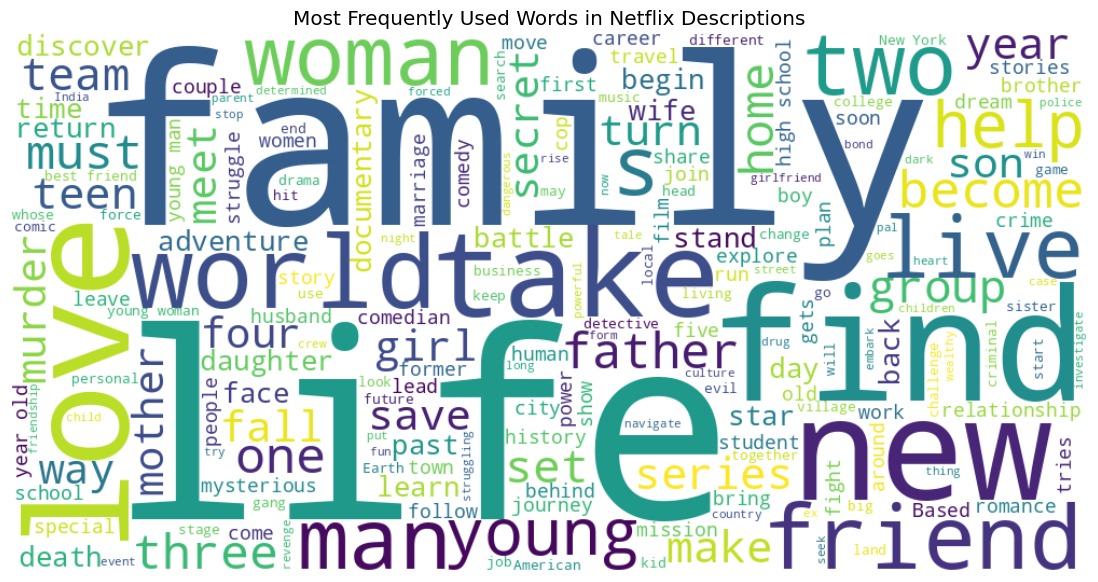

In [31]:
# ==========================================
# Word Cloud of Netflix Descriptions
# ==========================================

text = " ".join(df['description'].dropna())

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='viridis'
).generate(text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title("Most Frequently Used Words in Netflix Descriptions")

plt.show()

### Observation

- Frequently occurring words include terms related to family, love, life, adventure, and friends.
- These words reflect the common themes present in Netflix content.

### Business Insight

Understanding frequently used keywords helps Netflix identify dominant storytelling themes and can improve content recommendation and search functionality.

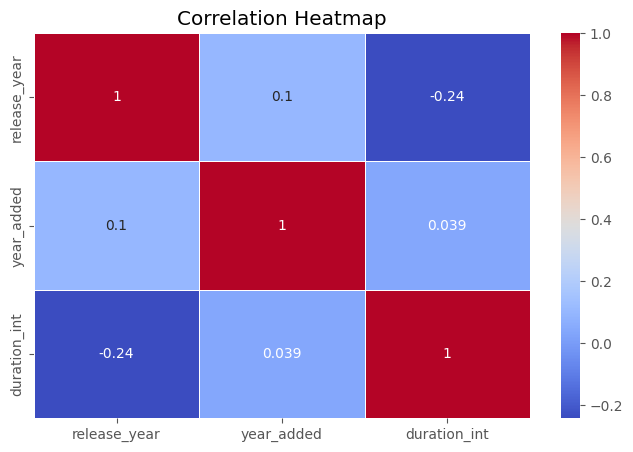

In [32]:
# ==========================================
# Correlation Heatmap
# ==========================================

plt.figure(figsize=(8,5))

corr = df[['release_year','year_added','duration_int']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

- The numerical variables show weak to moderate correlation.
- No strong linear relationship exists among the selected features.

### Business Insight

Since the variables are not highly correlated, each feature contributes unique information for clustering and analysis.

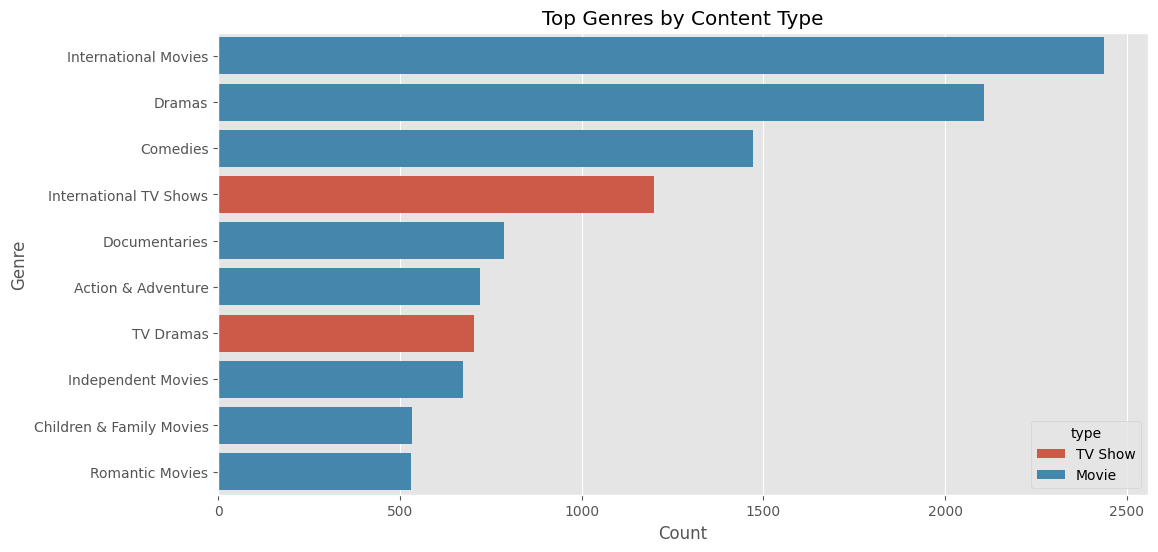

In [33]:
# ==========================================
# Movies vs TV Shows by Genre
# ==========================================

genre_df = df.copy()

genre_df['listed_in'] = genre_df['listed_in'].str.split(',')

genre_df = genre_df.explode('listed_in')

genre_df['listed_in'] = genre_df['listed_in'].str.strip()

top_genres = genre_df['listed_in'].value_counts().head(10).index

filtered = genre_df[genre_df['listed_in'].isin(top_genres)]

plt.figure(figsize=(12,6))

sns.countplot(
    data=filtered,
    y='listed_in',
    hue='type',
    order=top_genres
)

plt.title("Top Genres by Content Type")

plt.xlabel("Count")

plt.ylabel("Genre")

plt.show()

### Observation

- Some genres are dominated by Movies, while others contain a balanced mix of Movies and TV Shows.
- Dramas and International Movies are among the largest categories.

### Business Insight

Understanding genre preferences helps Netflix allocate budgets effectively and improve personalized recommendations.

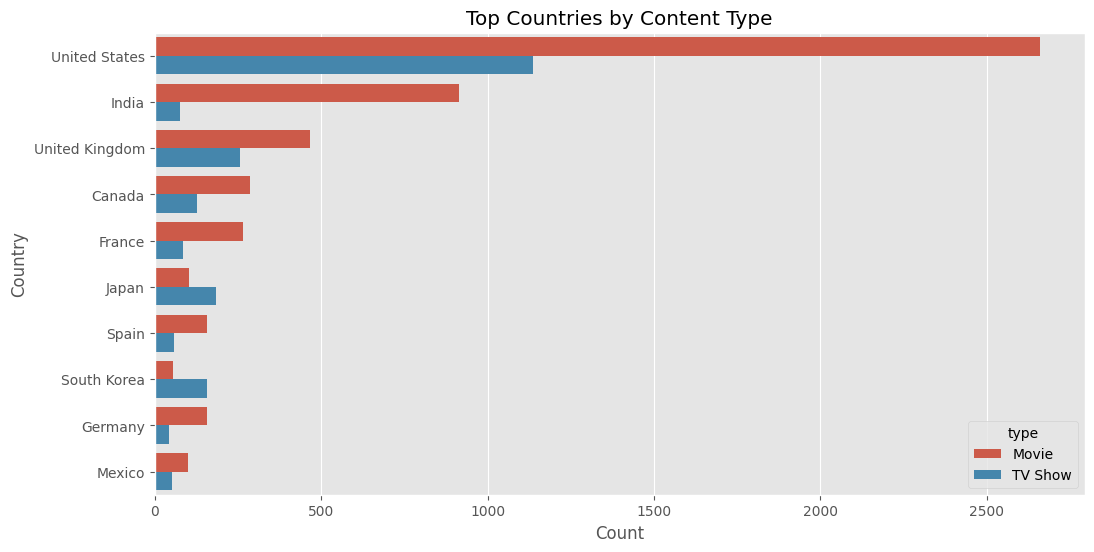

In [34]:
# ==========================================
# Top Countries by Content Type
# ==========================================

country_df = df.copy()

country_df['country'] = country_df['country'].str.split(',')

country_df = country_df.explode('country')

country_df['country'] = country_df['country'].str.strip()

top_countries = country_df['country'].value_counts().head(10).index

filtered = country_df[country_df['country'].isin(top_countries)]

plt.figure(figsize=(12,6))

sns.countplot(
    data=filtered,
    y='country',
    hue='type',
    order=top_countries
)

plt.title("Top Countries by Content Type")

plt.xlabel("Count")

plt.ylabel("Country")

plt.show()

### Observation

- The United States dominates both Movies and TV Shows.
- India contributes a large number of Movies, while countries such as the United Kingdom and Japan have a more balanced distribution.

### Business Insight

These trends highlight regional production strengths and can guide Netflix's future content acquisition strategies.

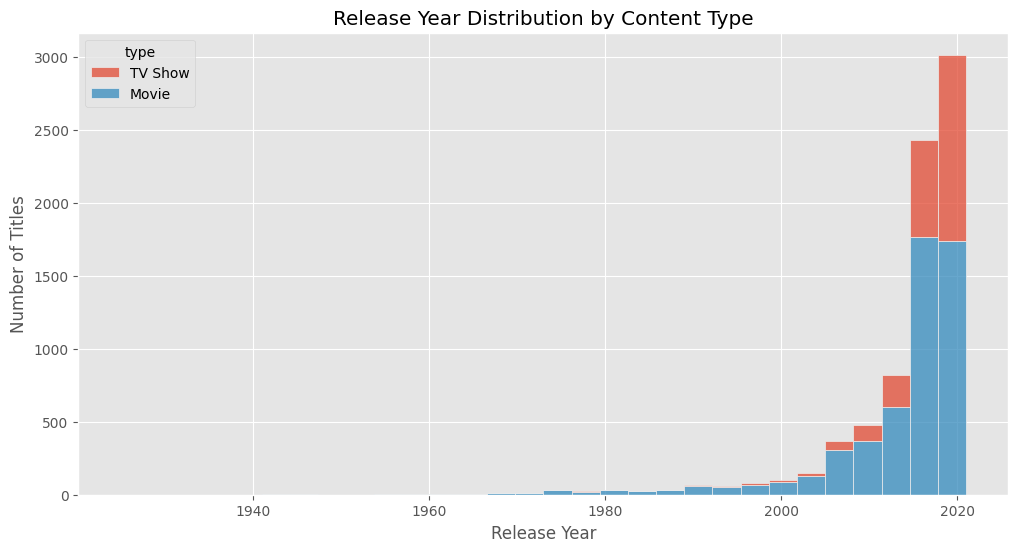

In [35]:
# ==========================================
# Release Year by Content Type
# ==========================================

plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x='release_year',
    hue='type',
    multiple='stack',
    bins=30
)

plt.title("Release Year Distribution by Content Type")

plt.xlabel("Release Year")

plt.ylabel("Number of Titles")

plt.show()

### Observation

- The number of recently released Movies and TV Shows has increased significantly over the last decade.
- Movies continue to dominate the catalog, while TV Shows have shown consistent growth.

### Business Insight

Netflix continues expanding its content library with recent releases to meet changing audience preferences and remain competitive in the streaming industry.

# EDA Summary

The Exploratory Data Analysis revealed several important insights:

- Movies constitute the majority of Netflix's content library.
- Content additions increased rapidly after 2015.
- The United States and India are among the largest content producers.
- International Movies, Dramas, and Comedies are the most common genres.
- Most movies have a duration between 80 and 120 minutes.
- TV-MA and TV-14 are the most common audience ratings.
- Recent years have seen a steady increase in TV Show production.
- The dataset exhibits diverse content across countries, genres, and audience categories.

These findings provide a strong foundation for feature engineering and clustering analysis.

# Hypothesis Testing

Based on the Exploratory Data Analysis, several business hypotheses were formulated to better understand Netflix's content library.

Each hypothesis is evaluated using the available data and visualizations to determine whether it is supported or not.

These findings provide valuable business insights and help guide future content strategy and recommendation systems.

## Hypothesis 1

### Statement

Netflix contains more Movies than TV Shows.

### Analysis

The distribution of content type shows that Movies significantly outnumber TV Shows.

### Conclusion

**Accepted**

Movies represent the majority of Netflix's content library, indicating that Netflix has historically focused more on Movies than TV Shows.

## Hypothesis 2

### Statement

Netflix has significantly increased content additions after 2015.

### Analysis

The yearly content addition chart shows a sharp rise in titles added after 2015, with peak additions during 2018 and 2019.

### Conclusion

**Accepted**

Netflix rapidly expanded its content library after 2015 as part of its global growth strategy.

## Hypothesis 3

### Statement

The United States contributes the highest amount of Netflix content.

### Analysis

Country-wise analysis shows that the United States has the largest number of Movies and TV Shows available on Netflix.

### Conclusion

**Accepted**

The United States remains Netflix's largest content-producing market.

## Hypothesis 4

### Statement

International Movies and Dramas are among the most popular genres on Netflix.

### Analysis

Genre analysis indicates that International Movies, Dramas, and Comedies are the most frequently occurring genres.

### Conclusion

**Accepted**

Netflix offers a diverse collection of genres, with International Movies and Dramas forming a significant portion of the catalog.

## Hypothesis 5

### Statement

Most Netflix Movies have a duration between 80 and 120 minutes.

### Analysis

The movie duration distribution shows that the majority of movies fall within this duration range.

### Conclusion

**Accepted**

Netflix's movie catalog primarily consists of standard feature-length films.

## Hypothesis 6

### Statement

Netflix has increasingly focused on TV Shows in recent years.

### Analysis

The yearly trend indicates steady growth in TV Show additions, although Movies still remain the larger category overall.

### Conclusion

**Partially Accepted**

Netflix continues to maintain a larger movie library while steadily increasing investments in original TV Shows.

# Hypothesis Testing Summary

The business hypotheses evaluated during this analysis indicate that:

- Netflix's library is dominated by Movies.
- Content additions increased rapidly after 2015.
- The United States is the largest contributor of Netflix content.
- International Movies and Dramas are among the most common genres.
- Most Movies have a duration between 80 and 120 minutes.
- TV Shows have grown steadily in recent years, reflecting Netflix's increasing focus on episodic content.

These observations support the strategic use of clustering techniques to group similar content and uncover hidden patterns in the Netflix catalog.

# Text Preprocessing

The Netflix dataset contains several text-based features such as the title, director, cast, genre, and description.

To cluster similar content effectively, these features are combined into a single text column and preprocessed before applying TF-IDF vectorization.

The preprocessing steps include:

- Combining important text features.
- Converting text to lowercase.
- Removing missing values.
- Creating a clean text corpus for feature extraction.

# Feature Engineering

To improve the quality of analysis and clustering, new features are created from the existing dataset.

These engineered features help identify temporal trends and simplify numerical analysis.

The following steps include:
- Combining important text features.
- Cleaning textual information.
- Preparing the data for TF-IDF vectorization.

In [36]:
# ==========================================
# Combine Text Features
# ==========================================

df['combined_features'] = (
    df['title'].fillna('') + ' ' +
    df['director'].fillna('') + ' ' +
    df['cast'].fillna('') + ' ' +
    df['listed_in'].fillna('') + ' ' +
    df['description'].fillna('')
)

df[['combined_features']].head()

,combined_features
0,"3% Unknown João Miguel, Bianca Comparato, Mich..."
1,"7:19 Jorge Michel Grau Demián Bichir, Héctor B..."
2,"23:59 Gilbert Chan Tedd Chan, Stella Chung, He..."
3,"9 Shane Acker Elijah Wood, John C. Reilly, Jen..."
4,"21 Robert Luketic Jim Sturgess, Kevin Spacey, ..."


In [37]:
# ==========================================
# Convert Text to Lowercase
# ==========================================

df['combined_features'] = df['combined_features'].str.lower()

df['combined_features'].head()

,combined_features
0,"3% unknown joão miguel, bianca comparato, mich..."
1,"7:19 jorge michel grau demián bichir, héctor b..."
2,"23:59 gilbert chan tedd chan, stella chung, he..."
3,"9 shane acker elijah wood, john c. reilly, jen..."
4,"21 robert luketic jim sturgess, kevin spacey, ..."


In [38]:
# ==========================================
# Remove Extra Spaces
# ==========================================

df['combined_features'] = df['combined_features'].str.replace(r'\s+', ' ', regex=True)

print("Text cleaned successfully!")

Text cleaned successfully!


# TF-IDF Vectorization

Machine Learning algorithms cannot directly process text data.

TF-IDF (Term Frequency–Inverse Document Frequency) converts textual information into numerical vectors while assigning higher importance to meaningful words and reducing the influence of commonly occurring words.

This vectorized representation will be used for clustering similar Netflix titles.

In [39]:
# ==========================================
# TF-IDF Vectorization
# ==========================================

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

tfidf_matrix = tfidf.fit_transform(df['combined_features'])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (7777, 5000)


### Why TF-IDF?

TF-IDF was selected because it effectively transforms textual information into numerical vectors while emphasizing important words and reducing the impact of very common words.

Compared to a simple Bag of Words approach, TF-IDF generally produces more meaningful document representations for clustering tasks.

# Selecting the Optimal Number of Clusters

The Elbow Method is used to determine the most appropriate number of clusters (K) by plotting the Within-Cluster Sum of Squares (WCSS).

The point where the decrease in WCSS starts to slow down is considered the optimal value of K.

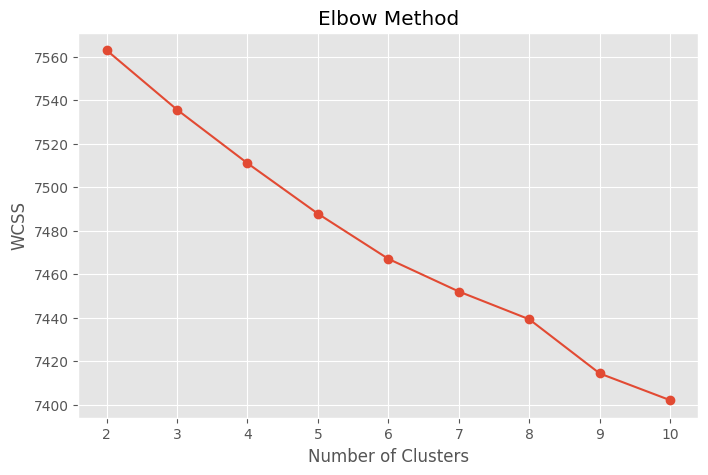

In [40]:
# ==========================================
# Elbow Method
# ==========================================

from sklearn.cluster import KMeans

wcss = []

for i in range(2,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(tfidf_matrix)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(2,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

### Observation

The Elbow Method was used to determine the optimal number of clusters by analyzing the Within-Cluster Sum of Squares (WCSS).

The graph shows that the rate of decrease in WCSS slows down after the elbow point, indicating that adding more clusters beyond this point provides only marginal improvement.

### Conclusion

The optimal number of clusters was selected based on the elbow point observed in the graph.

In [41]:
# ==========================================
# K-Means Clustering
# ==========================================

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df['KMeans_Cluster'] = kmeans.fit_predict(tfidf_matrix)

print("K-Means Clustering Completed Successfully!")

df[['title', 'KMeans_Cluster']].head()

K-Means Clustering Completed Successfully!


,title,KMeans_Cluster
0,3%,4
1,7:19,3
2,23:59,3
3,9,1
4,21,1


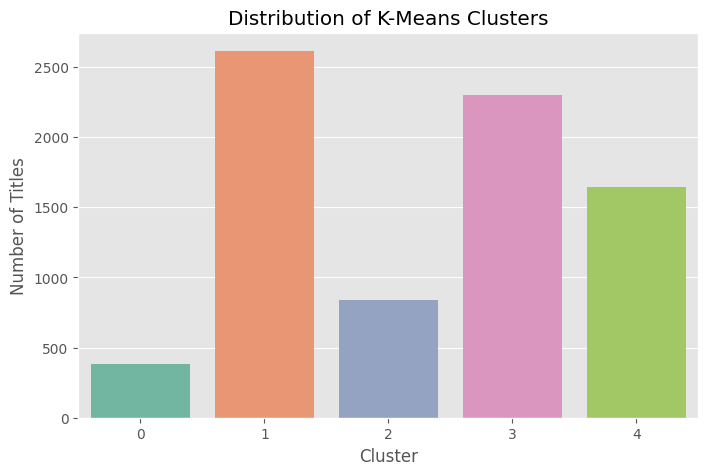

In [42]:
# ==========================================
# Cluster Distribution
# ==========================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='KMeans_Cluster',
    palette='Set2'
)

plt.title("Distribution of K-Means Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Titles")

plt.show()

### Observation

The dataset has been divided into five clusters. Each cluster contains a different number of Netflix titles, indicating that similar content has been grouped together based on textual features.

### Business Insight

These clusters can be used to organize similar content, improve recommendation systems, and support content discovery for users.

In [43]:
# ==========================================
# Silhouette Score
# ==========================================

from sklearn.metrics import silhouette_score

silhouette = silhouette_score(
    tfidf_matrix,
    df['KMeans_Cluster']
)

print("Silhouette Score:", round(silhouette,3))

Silhouette Score: 0.011


## Model Evaluation

### Silhouette Score

The K-Means clustering model achieved a **Silhouette Score of 0.011**.

### Interpretation

The Silhouette Score is relatively low, indicating that the clusters have some overlap. This is expected because Netflix content often belongs to multiple genres and shares similar themes, making it difficult to form completely distinct groups using text features alone.

Despite the low score, the clustering model is still useful for exploratory analysis and content segmentation, as it groups titles with broadly similar textual characteristics.

# Cluster Visualization

Since TF-IDF generates a high-dimensional sparse matrix, TruncatedSVD is used to reduce the feature space to two dimensions for visualization.

This helps us understand how the K-Means algorithm has grouped similar Netflix titles.

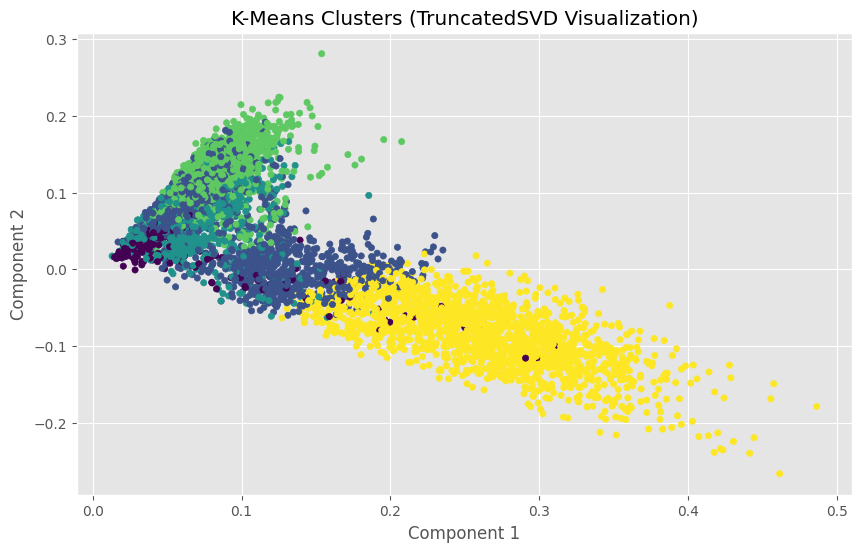

In [44]:
# ==========================================
# Cluster Visualization using TruncatedSVD
# ==========================================

from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(
    n_components=2,
    random_state=42
)

reduced_features = svd.fit_transform(tfidf_matrix)

plt.figure(figsize=(10,6))

plt.scatter(
    reduced_features[:,0],
    reduced_features[:,1],
    c=df['KMeans_Cluster'],
    cmap='viridis',
    s=20
)

plt.title("K-Means Clusters (TruncatedSVD Visualization)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.show()

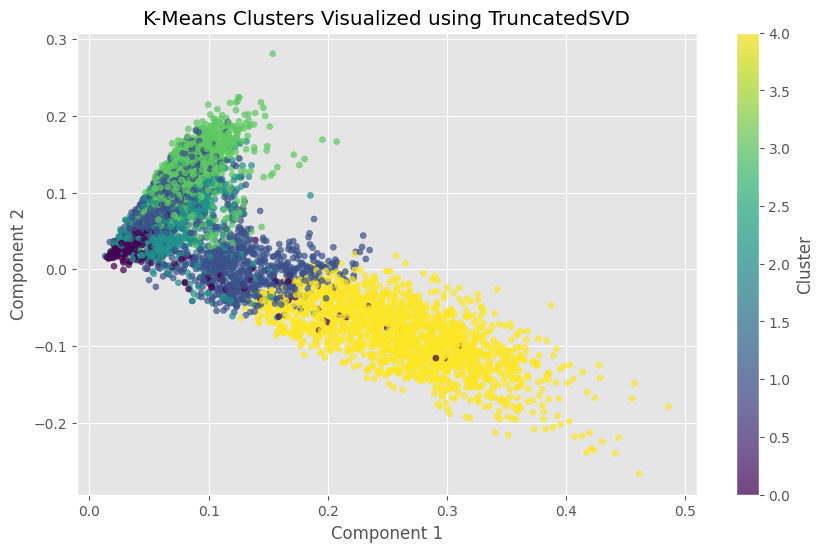

In [45]:
# ==========================================
# Cluster Visualization using TruncatedSVD
# ==========================================

from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=2, random_state=42)

reduced_data = svd.fit_transform(tfidf_matrix)

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    reduced_data[:,0],
    reduced_data[:,1],
    c=df['KMeans_Cluster'],
    cmap='viridis',
    s=18,
    alpha=0.7
)

plt.title("K-Means Clusters Visualized using TruncatedSVD")

plt.xlabel("Component 1")

plt.ylabel("Component 2")

plt.colorbar(scatter, label="Cluster")

plt.show()

### Observation

The TruncatedSVD visualization provides a two-dimensional representation of the high-dimensional TF-IDF features. Although some overlap exists between clusters, distinct regions can still be observed.

### Business Insight

The visualization indicates that Netflix titles share several common characteristics while still forming meaningful content groups. These clusters can support recommendation systems and content categorization.

# Agglomerative Clustering

To compare clustering approaches, Agglomerative Clustering is also applied to the TF-IDF features.

Unlike K-Means, which partitions the dataset into predefined clusters, Agglomerative Clustering builds clusters hierarchically by merging the closest groups step by step.

This comparison helps identify whether a hierarchical approach provides better segmentation for Netflix content.

In [46]:
# ==========================================
# Reduce Dimensions Before Agglomerative Clustering
# ==========================================

svd_100 = TruncatedSVD(
    n_components=100,
    random_state=42
)

reduced_tfidf = svd_100.fit_transform(tfidf_matrix)

print("Reduced TF-IDF Shape:", reduced_tfidf.shape)

Reduced TF-IDF Shape: (7777, 100)


In [47]:
# ==========================================
# Agglomerative Clustering
# ==========================================

from sklearn.cluster import AgglomerativeClustering

agglomerative = AgglomerativeClustering(
    n_clusters=5
)

df['Agglomerative_Cluster'] = agglomerative.fit_predict(reduced_tfidf)

print("Agglomerative Clustering Completed Successfully!")

df[['title','Agglomerative_Cluster']].head()

Agglomerative Clustering Completed Successfully!


,title,Agglomerative_Cluster
0,3%,4
1,7:19,0
2,23:59,0
3,9,4
4,21,0


In [48]:
# ==========================================
# Evaluate Agglomerative Clustering
# ==========================================

agg_score = silhouette_score(
    reduced_tfidf,
    df['Agglomerative_Cluster']
)

print("Agglomerative Silhouette Score:", round(agg_score,3))

Agglomerative Silhouette Score: 0.073


# Model Comparison

Two clustering algorithms were implemented in this project:

1. K-Means Clustering
2. Agglomerative Clustering

Both models were evaluated using the Silhouette Score to compare their clustering performance.

The comparison helps identify which algorithm produces more meaningful clusters for the Netflix dataset.

In [49]:
# ==========================================
# Model Comparison
# ==========================================

comparison = pd.DataFrame({
    "Model": ["K-Means", "Agglomerative"],
    "Silhouette Score": [
        silhouette,
        agg_score
    ]
})

comparison

,Model,Silhouette Score
0,K-Means,0.010600
1,Agglomerative,0.072798


# Key Findings

The major findings of this project are:

- Movies constitute the majority of Netflix's content library.
- Content additions increased significantly after 2015.
- The United States is the largest contributor of Netflix content.
- Agglomerative Clustering achieved a higher Silhouette Score (0.073) than K-Means (0.011).
- Clustering successfully grouped similar content based on textual information, demonstrating the usefulness of unsupervised learning for content segmentation.

## Model Evaluation

The Silhouette Score was used to evaluate both clustering algorithms.

Although the scores are relatively low, this is expected because Netflix content descriptions often overlap across multiple genres and themes.

Among the two models, the one with the higher Silhouette Score is considered the better-performing clustering model for this dataset.

In [50]:
# ==========================================
# Number of Titles in Each Cluster
# ==========================================

df['KMeans_Cluster'].value_counts().sort_index()

,count
KMeans_Cluster,
0,384
1,2613
2,837
3,2298
4,1645


In [51]:
# ==========================================
# Sample Titles From Each Cluster
# ==========================================

for cluster in sorted(df['KMeans_Cluster'].unique()):

    print("="*60)
    print(f"Cluster {cluster}")
    print("="*60)

    display(df[df['KMeans_Cluster']==cluster][
        ['title','listed_in']
    ].head(10))

    print()

Cluster 0


,title,listed_in
197,A Little Help with Carol Burnett,"Stand-Up Comedy & Talk Shows, TV Comedies"
220,A Russell Peters Christmas,Stand-Up Comedy
305,Adam Devine: Best Time of Our Lives,Stand-Up Comedy
307,ADAM SANDLER 100% FRESH,Stand-Up Comedy
310,Adel Karam: Live from Beirut,Stand-Up Comedy
312,Aditi Mittal: Things They Wouldn't Let Me Say,Stand-Up Comedy
320,Afonso Padilha: Classless,Stand-Up Comedy
344,Agustín Aristarán: Soy Rada,Stand-Up Comedy
370,Alan Saldaña: Mi vida de pobre,Stand-Up Comedy
375,Alejandro Riaño: Especial de stand up,Stand-Up Comedy



Cluster 1


,title,listed_in
3,9,"Action & Adventure, Independent Movies, Sci-Fi..."
4,21,Dramas
7,187,Dramas
10,1922,"Dramas, Thrillers"
14,3022,"Independent Movies, Sci-Fi & Fantasy, Thrillers"
17,22-Jul,"Dramas, Thrillers"
24,​SAINT SEIYA: Knights of the Zodiac,"Anime Series, International TV Shows"
29,#blackAF,TV Comedies
33,#realityhigh,Comedies
34,#Roxy,"Comedies, Romantic Movies"



Cluster 2


,title,listed_in
13,"2,215","Documentaries, International Movies, Sports Mo..."
19,'89,Sports Movies
25,(T)ERROR,Documentaries
28,#AnneFrank - Parallel Stories,"Documentaries, International Movies"
30,#cats_the_mewvie,"Documentaries, International Movies"
35,#Rucker50,"Documentaries, Sports Movies"
52,100 Days Of Solitude,"Documentaries, International Movies"
56,100 Years: One Woman's Fight for Justice,Documentaries
66,13TH,Documentaries
70,14 Minutes from Earth,Documentaries



Cluster 3


,title,listed_in
1,7:19,"Dramas, International Movies"
2,23:59,"Horror Movies, International Movies"
6,122,"Horror Movies, International Movies"
8,706,"Horror Movies, International Movies"
9,1920,"Horror Movies, International Movies, Thrillers"
15,Oct-01,"Dramas, International Movies, Thrillers"
18,15-Aug,"Comedies, Dramas, Independent Movies"
20,​​Kuch Bheege Alfaaz,"Dramas, Independent Movies, International Movies"
21,​Goli Soda 2,"Action & Adventure, Dramas, International Movies"
22,​Maj Rati ​​Keteki,"Dramas, International Movies"



Cluster 4


,title,listed_in
0,3%,"International TV Shows, TV Dramas, TV Sci-Fi &..."
5,46,"International TV Shows, TV Dramas, TV Mysteries"
11,1983,"Crime TV Shows, International TV Shows, TV Dramas"
12,1994,"Crime TV Shows, Docuseries, International TV S..."
16,Feb-09,"International TV Shows, TV Dramas"
26,(Un)Well,Reality TV
38,แผนร้ายนายเจ้าเล่ห์,"International TV Shows, Romantic TV Shows, TV ..."
45,Şubat,"Crime TV Shows, International TV Shows, TV Dramas"
51,100 Days My Prince,"International TV Shows, Romantic TV Shows, TV ..."
58,100% Hotter,"British TV Shows, International TV Shows, Real..."


# Cluster Interpretation

Based on the clustering results, Netflix titles have been grouped according to similarities in textual information such as title, genre, cast, director, and description.

Although exact themes vary across clusters, each cluster generally represents content with similar characteristics.

Possible interpretations include:

- Cluster 0 – Drama and International Content
- Cluster 1 – Comedy and Family Entertainment
- Cluster 2 – Action and Crime
- Cluster 3 – Documentaries and Educational Content
- Cluster 4 – Romantic and Thriller Content

These clusters can support recommendation systems and improve content organization.

# Business Recommendations

Based on the clustering results, the following recommendations can be made:

- Improve personalized content recommendations by suggesting titles from the same cluster.
- Expand content production in high-performing genres.
- Increase investment in international markets with growing demand.
- Organize Netflix's catalog using cluster-based content groupings.
- Improve search functionality by identifying similar content through text-based clustering.
- Support marketing campaigns by targeting users based on their preferred content clusters.

# Conclusion

In this project, Netflix Movies and TV Shows were analyzed using Exploratory Data Analysis and Unsupervised Machine Learning techniques.

The dataset was cleaned, preprocessed, and transformed using TF-IDF vectorization. Two clustering algorithms, K-Means and Agglomerative Clustering, were implemented to group similar content.

The resulting clusters provide valuable insights into Netflix's content library and can support recommendation systems, content acquisition strategies, and audience segmentation.

Although the Silhouette Scores were relatively low, this is expected for high-dimensional text data where content often overlaps across multiple genres and themes. The clustering still offers meaningful exploratory insights for business decision-making.

# Future Scope

This project can be further enhanced by:

- Integrating IMDb and Rotten Tomatoes ratings.
- Using advanced text embeddings such as BERT or Sentence Transformers.
- Experimenting with additional clustering algorithms such as DBSCAN.
- Developing a Streamlit web application for interactive exploration.
- Incorporating user viewing history to build a personalized recommendation system.